In [1]:
import random
import numpy as np
import torch
import torch.nn as nn

from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Load model pretrained

In [2]:
model = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)

## Thay classifier cho 10 class

In [3]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1000, bias=True)
)


In [4]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    10
)


## Đưa lên GPU

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"
AMP_ENABLED = device.type == "cuda"
AMP_DTYPE = (
    torch.bfloat16
    if AMP_ENABLED and torch.cuda.is_bf16_supported()
    else torch.float16
)

if device.type == "cuda":
    # Disable exhaustive cuDNN autotuning for predictable startup and VRAM use.
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

model = model.to(device, memory_format=torch.channels_last)
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED and AMP_DTYPE == torch.float16,
)

print(f"Device: {device}")
if device.type == "cuda":
    properties = torch.cuda.get_device_properties(0)
    print(f"GPU: {properties.name}")
    print(f"VRAM: {properties.total_memory / 1024**3:.1f} GB")
    print(f"AMP dtype: {AMP_DTYPE}")

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.0 GB
AMP dtype: torch.bfloat16


## Data Augmentation mới

### Train


In [6]:
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((300,300)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

### Val/Test

In [7]:
val_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [8]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    r"D:\KÌ 7\RiceDataset_Split\train",
    transform=train_transform
)

val_dataset = ImageFolder(
    r"D:\KÌ 7\RiceDataset_Split\val",
    transform=val_transform
)

test_dataset = ImageFolder(
    r"D:\KÌ 7\RiceDataset_Split\test",
    transform=test_transform
)

In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16
# num_workers=0 is the safest setting for Jupyter on Windows.
NUM_WORKERS = 0

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
}
if NUM_WORKERS > 0:
    loader_kwargs.update(
        persistent_workers=True,
        prefetch_factor=2,
    )

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, shuffle=True, generator=generator, **loader_kwargs
)
val_loader = DataLoader(
    val_dataset, shuffle=False, **loader_kwargs
)
test_loader = DataLoader(
    test_dataset, shuffle=False, **loader_kwargs
)

print(
    f"Batch size: {BATCH_SIZE}, workers: {NUM_WORKERS}, "
    f"pin_memory: {PIN_MEMORY}"
)

Batch size: 16, workers: 0, pin_memory: True


## Optimizer



In [10]:
FREEZE_EPOCHS = 5
WEIGHT_DECAY = 1e-3

def set_feature_extractor_trainable(model, trainable):
    for parameter in model.features.parameters():
        parameter.requires_grad = trainable

def create_optimizer(model, fine_tune=False):
    if fine_tune:
        return torch.optim.AdamW(
            [
                {"params": model.features.parameters(), "lr": 1e-5},
                {"params": model.classifier.parameters(), "lr": 1e-4},
            ],
            weight_decay=WEIGHT_DECAY,
        )

    return torch.optim.AdamW(
        model.classifier.parameters(),
        lr=3e-4,
        weight_decay=WEIGHT_DECAY,
    )

set_feature_extractor_trainable(model, False)
optimizer = create_optimizer(model, fine_tune=False)

## Loss Function

In [11]:
class_weights = np.load(
    "../data/class_weights.npy"
)

weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

## Scheduler

In [12]:
MIN_DELTA = 1e-3

def create_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        threshold=MIN_DELTA,
        threshold_mode="abs",
        min_lr=1e-7,
    )

scheduler = create_scheduler(optimizer)

### Hàm train

In [13]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    freeze_features=False
):

    model.train()
    if freeze_features:
        # Keep pretrained BatchNorm statistics fixed during classifier warm-up.
        model.features.eval()

    running_loss = 0

    for batch_idx, (images, labels) in enumerate(loader):

        images = images.to(
            device,
            non_blocking=PIN_MEMORY,
            memory_format=torch.channels_last,
        )
        labels = labels.to(device, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=device.type,
            dtype=AMP_DTYPE,
            enabled=AMP_ENABLED,
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f"Non-finite loss at batch {batch_idx}: {loss.item()}"
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            (p for p in model.parameters() if p.requires_grad),
            max_norm=1.0,
        )
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)

In [14]:
# for name, param in model.named_parameters():

#     if torch.isnan(param).any():

#         print("NaN:", name)

## Validation


In [15]:
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(
                device,
                non_blocking=PIN_MEMORY,
                memory_format=torch.channels_last,
            )
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            with torch.autocast(
                device_type=device.type,
                dtype=AMP_DTYPE,
                enabled=AMP_ENABLED,
            ):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total

## Training Loop

In [16]:
MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 5
best_val_loss = float("inf")
best_val_acc = 0.0
epochs_without_improvement = 0

if device.type == "cuda":
    torch.cuda.empty_cache()

for epoch in range(MAX_EPOCHS):
    if epoch == FREEZE_EPOCHS:
        set_feature_extractor_trainable(model, True)
        optimizer = create_optimizer(model, fine_tune=True)
        scheduler = create_scheduler(optimizer)
        epochs_without_improvement = 0
        print("Unfreezing EfficientNet-B3 features for fine-tuning.")

    freeze_features = epoch < FREEZE_EPOCHS
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    try:
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            freeze_features=freeze_features,
        )
    except torch.OutOfMemoryError as error:
        if device.type == "cuda":
            torch.cuda.empty_cache()
        raise RuntimeError(
            "CUDA ran out of memory. Set BATCH_SIZE to 8 and rerun "
            "the DataLoader and training cells."
        ) from error

    val_loss, val_acc = evaluate(
        model, val_loader, criterion
    )
    scheduler.step(val_loss)

    learning_rates = [group["lr"] for group in optimizer.param_groups]
    stage = "classifier" if freeze_features else "fine-tune"
    peak_memory = (
        torch.cuda.max_memory_allocated() / 1024**3
        if device.type == "cuda"
        else 0.0
    )
    print(
        f"Epoch {epoch + 1:02d} [{stage}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {learning_rates} | Peak VRAM: {peak_memory:.2f} GB"
    )

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "../models/best_efficientnet_b3.pth")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping.")
        break

model.load_state_dict(
    torch.load(
        "../models/best_efficientnet_b3.pth",
        map_location=device,
        weights_only=True,
    )
)
print(
    f"Best Val Loss: {best_val_loss:.4f} | "
    f"Val Acc at best loss: {best_val_acc:.4f}"
)

Epoch 01 [classifier] | Train Loss: 1.4587 | Val Loss: 1.1639 | Val Acc: 0.6146 | LR: [0.0003] | Peak VRAM: 0.28 GB
Epoch 02 [classifier] | Train Loss: 1.0278 | Val Loss: 0.9958 | Val Acc: 0.6539 | LR: [0.0003] | Peak VRAM: 0.28 GB
Epoch 03 [classifier] | Train Loss: 0.9020 | Val Loss: 0.9227 | Val Acc: 0.6747 | LR: [0.0003] | Peak VRAM: 0.28 GB
Epoch 04 [classifier] | Train Loss: 0.8280 | Val Loss: 0.8706 | Val Acc: 0.6911 | LR: [0.0003] | Peak VRAM: 0.28 GB
Epoch 05 [classifier] | Train Loss: 0.7830 | Val Loss: 0.8397 | Val Acc: 0.6819 | LR: [0.0003] | Peak VRAM: 0.28 GB
Unfreezing EfficientNet-B3 features for fine-tuning.
Epoch 06 [fine-tune] | Train Loss: 1.2224 | Val Loss: 0.8747 | Val Acc: 0.6823 | LR: [1e-05, 0.0001] | Peak VRAM: 2.54 GB
Epoch 07 [fine-tune] | Train Loss: 0.9071 | Val Loss: 0.9716 | Val Acc: 0.7427 | LR: [1e-05, 0.0001] | Peak VRAM: 2.54 GB
Epoch 08 [fine-tune] | Train Loss: 0.7633 | Val Loss: 0.6229 | Val Acc: 0.7735 | LR: [1e-05, 0.0001] | Peak VRAM: 2.54 GB
E

## Load model tốt nhất

In [17]:
model.load_state_dict(
    torch.load(
        "../models/best_efficientnet_b3.pth",
        map_location=device,
        weights_only=True,
    )
)

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

## Đánh giá trên test set

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_true = []
y_pred = []

with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=PIN_MEMORY,
            memory_format=torch.channels_last,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=AMP_DTYPE,
            enabled=AMP_ENABLED,
        ):
            outputs = model(images)

        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

## Accuracy

In [19]:
acc = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", acc)

Accuracy: 0.8759503801520608


## Precision Recall F1

In [20]:
print(
    "Precision:",
    precision_score(
        y_true,
        y_pred,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_true,
        y_pred,
        average="weighted"
    )
)

print(
    "F1:",
    f1_score(
        y_true,
        y_pred,
        average="weighted"
    )
)

Precision: 0.8773968348610875
Recall: 0.8759503801520608
F1: 0.8757865803067946


## Classification Report

In [21]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_dataset.classes
    )
)

                 precision    recall  f1-score   support

BacterialBlight       0.97      0.95      0.96       244
          Blast       0.95      0.95      0.95       339
      BrownSpot       0.97      0.96      0.97       329
      DeadHeart       1.00      0.98      0.99       202
        Healthy       0.96      1.00      0.98       337
     LeafDamage       0.65      0.69      0.67       131
 OtherRicePests       0.78      0.68      0.73       408
    Planthopper       0.69      0.77      0.73       280
   SheathBlight       0.98      0.98      0.98        94
      StemBorer       0.73      0.78      0.75       135

       accuracy                           0.88      2499
      macro avg       0.87      0.88      0.87      2499
   weighted avg       0.88      0.88      0.88      2499



## Confusion Matrix

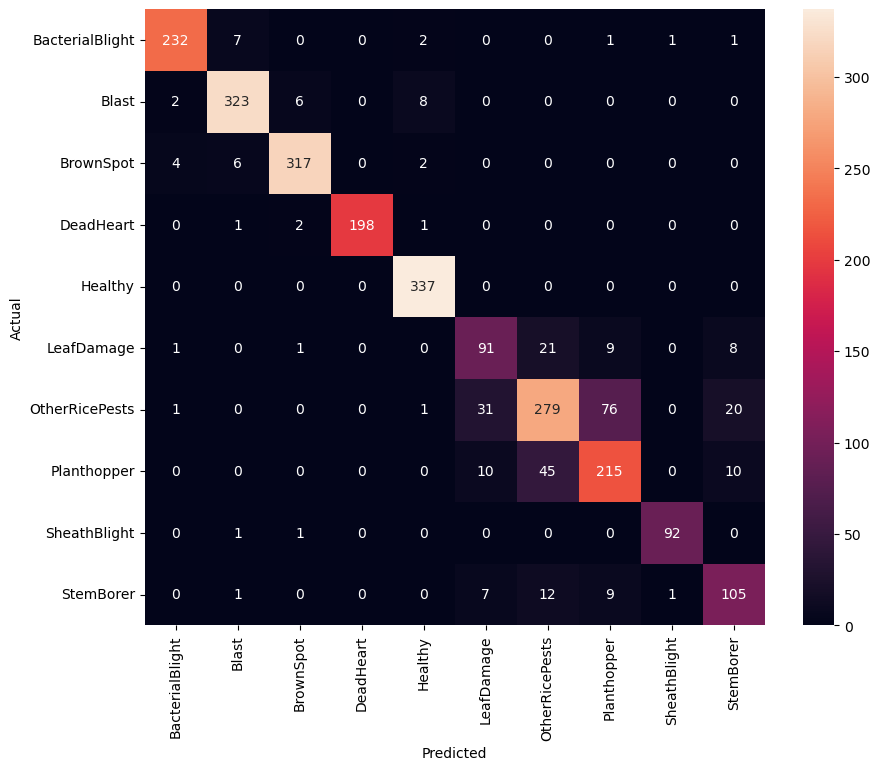

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()